# Predictive model for D30 retention

Different goal from notebooks 02 and 03. The causal notebooks asked, what is the effect of getting an answer? This one asks, given everything we know at first-post time, can we predict whether a new contributor will be active 30 days from now? That's the question a product team would ask if they wanted to flag at-risk users for an outreach intervention.

Four versions, in order of escalating effort. v1 is the baseline with 14 raw features and untuned models. v2 adds engineered features: tag one-hots, polynomials on body and title length, time-of-day buckets, and interactions involving the treatment. v3 runs a randomized hyperparameter search on the gradient booster. v4 calibrates the tuned model with sigmoid (Platt) scaling.

The headline finding is that v1 to v4 buys roughly half a percentage point of ROC AUC. The structural ceiling for this feature set, in particular without text content of the question body or title, sits around 0.64. Pushing further would require text features (TF-IDF or embeddings on body and title), which is out of scope here but flagged.

In [1]:
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, brier_score_loss

import shap
import db_dtypes  # noqa: F401

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = '../data/processed'
RNG = 42

C:\Users\bassi\Downloads\DS_ML_PL_DE_DA\stackoverflow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data, engineer features

Loading master.parquet plus cohort.parquet for primary_tag. The 14 v1 features are the columns already in master.parquet. The v2 additions are constructed here so the comparison is purely about what the engineered features and tuning buy us, not about which features were available.

In [2]:
df = pq.read_table(f'{DATA_DIR}/master.parquet').to_pandas()
df['log_body_length'] = np.log(df['body_length'].clip(lower=1))
df['cohort_year'] = pd.to_datetime(df['cohort_month']).dt.year

# Primary tag from cohort.parquet for the language-bucket feature
cohort = pq.read_table(f'{DATA_DIR}/cohort.parquet').to_pandas()
df = df.merge(cohort[['user_id', 'first_tag']], on='user_id', how='left')
df['primary_tag'] = df['first_tag'].astype(str).str.split('|').str[0]

# Cast Int64 -> float for sklearn compatibility
for col in ['active_d30', 'got_answer_within_24h', 'got_answer_within_1h', 'got_any_answer',
             'has_code_block', 'has_link', 'has_image', 'is_weekend',
             'title_length', 'num_tags', 'hour_of_day_utc', 'day_of_week']:
    df[col] = df[col].astype(float)
df['hours_to_first_answer'] = df['hours_to_first_answer'].astype(float).fillna(-1)

print(f'Loaded master + cohort: {len(df):,} rows')
print(f'Base D30 rate: {df["active_d30"].mean():.3f}')
print(f'Distinct primary tags: {df["primary_tag"].nunique():,}')

Loaded master + cohort: 1,772,119 rows
Base D30 rate: 0.240
Distinct primary tags: 13,532


In [3]:
# v1 feature set: 14 columns from master.parquet, no engineering
v1_features = [
    'log_body_length', 'title_length', 'has_code_block', 'has_link', 'has_image',
    'num_tags', 'hour_of_day_utc', 'day_of_week', 'is_weekend',
    'got_any_answer', 'got_answer_within_24h', 'got_answer_within_1h',
    'hours_to_first_answer', 'cohort_year',
]

# v2 additions: polynomials, time buckets, interactions, plus tag one-hots
df['log_body_length_sq'] = df['log_body_length'] ** 2
df['title_length_sq'] = df['title_length'] ** 2
df['log_hours_to_answer'] = np.where(df['hours_to_first_answer'] > 0,
                                       np.log1p(df['hours_to_first_answer']), -1.0)
df['peak_hour'] = ((df['hour_of_day_utc'] >= 13) & (df['hour_of_day_utc'] <= 15)).astype(float)
df['overnight_hour'] = ((df['hour_of_day_utc'] >= 0) & (df['hour_of_day_utc'] <= 5)).astype(float)
df['ans_x_code'] = df['got_any_answer'] * df['has_code_block']
df['ans_x_logbody'] = df['got_any_answer'] * df['log_body_length']
df['htfa_x_code'] = df['log_hours_to_answer'] * df['has_code_block']

engineered_numeric = [
    'log_body_length_sq', 'title_length_sq', 'log_hours_to_answer',
    'peak_hour', 'overnight_hour',
    'ans_x_code', 'ans_x_logbody', 'htfa_x_code',
]
v2_numeric = v1_features + engineered_numeric

# Tag bucketing: top 30 by frequency plus 'other'
TOP_TAGS = df['primary_tag'].value_counts().head(30).index.tolist()
df['tag_bucket'] = df['primary_tag'].where(df['primary_tag'].isin(TOP_TAGS), 'other')

print(f'v1 features: {len(v1_features)}')
print(f'v2 numeric features: {len(v2_numeric)}')
print(f'v2 tag bucket categories: {df["tag_bucket"].nunique()}  (top 30 + other)')

v1 features: 14
v2 numeric features: 22
v2 tag bucket categories: 31  (top 30 + other)


In [4]:
# Build v1 and v2 feature matrices
X_v1 = df[v1_features].copy()
X_v2 = pd.concat([
    df[v2_numeric].reset_index(drop=True),
    pd.get_dummies(df['tag_bucket'], prefix='tag', drop_first=True).reset_index(drop=True).astype(float),
], axis=1)
y = df['active_d30'].astype(int)

# Single train/test split, used for both v1 and v2 so the comparison is apples-to-apples
X_train_v1, X_test_v1, y_train, y_test = train_test_split(
    X_v1, y, test_size=0.2, random_state=RNG, stratify=y
)
X_train_v2, X_test_v2, _, _ = train_test_split(
    X_v2, y, test_size=0.2, random_state=RNG, stratify=y
)

print(f'Train: {len(X_train_v1):,}  Test: {len(X_test_v1):,}')
print(f'Positive rate train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')
print(f'v1 feature matrix: {X_v1.shape}')
print(f'v2 feature matrix: {X_v2.shape}')

def metrics(name, y_true, prob):
    return {
        'model': name,
        'roc_auc': roc_auc_score(y_true, prob),
        'pr_auc': average_precision_score(y_true, prob),
        'brier': brier_score_loss(y_true, prob),
    }

Train: 1,417,695  Test: 354,424
Positive rate train: 0.240  test: 0.240
v1 feature matrix: (1772119, 14)
v2 feature matrix: (1772119, 52)


## 2. v1, baseline

Logistic regression with standardized features as the interpretable baseline. HistGradientBoostingClassifier with mostly-default hyperparameters as the non-linear comparison. No tuning, no calibration. This is the floor to beat.

In [5]:
logit_v1 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1)),
])
logit_v1.fit(X_train_v1, y_train)
logit_v1_prob = logit_v1.predict_proba(X_test_v1)[:, 1]

gbm_v1 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6, random_state=RNG)
gbm_v1.fit(X_train_v1, y_train)
gbm_v1_prob = gbm_v1.predict_proba(X_test_v1)[:, 1]

v1_results = [
    metrics('v1 Logit (baseline)', y_test, logit_v1_prob),
    metrics('v1 GBM (baseline)', y_test, gbm_v1_prob),
]
print(pd.DataFrame(v1_results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

              model  roc_auc  pr_auc  brier
v1 Logit (baseline)   0.6212  0.3310 0.1765
  v1 GBM (baseline)   0.6362  0.3517 0.1744


## 3. v2, engineered features

Same model class, same hyperparameters. The only thing that changes is the feature set, now 52 columns instead of 14. Tests whether the linear model was missing multiplicative effects and whether the gradient booster benefits from explicit categorical signal.

In [6]:
logit_v2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)),
])
logit_v2.fit(X_train_v2, y_train)
logit_v2_prob = logit_v2.predict_proba(X_test_v2)[:, 1]

gbm_v2 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6, random_state=RNG)
gbm_v2.fit(X_train_v2, y_train)
gbm_v2_prob = gbm_v2.predict_proba(X_test_v2)[:, 1]

v2_results = [
    metrics('v2 Logit (engineered features)', y_test, logit_v2_prob),
    metrics('v2 GBM (engineered features)', y_test, gbm_v2_prob),
]
print(pd.DataFrame(v2_results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

                         model  roc_auc  pr_auc  brier
v2 Logit (engineered features)   0.6250  0.3344 0.1761
  v2 GBM (engineered features)   0.6406  0.3560 0.1740


## 4. v3, hyperparameter-tuned GBM

Randomized search over GBM hyperparameters on a 200K-row subsample of train. Then refit the best on the full train set. Tuning on the full 1.4M-row train would take much longer without changing the result, the subsample picks settings well enough.

In [7]:
tune_idx = np.random.RandomState(RNG).choice(len(X_train_v2), size=200_000, replace=False)
X_tune = X_train_v2.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]

param_dist = {
    'max_iter': [200, 400, 600, 800],
    'learning_rate': [0.02, 0.05, 0.08, 0.1],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [20, 50, 100, 200],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RNG, early_stopping=True, validation_fraction=0.15),
    param_dist, n_iter=20, scoring='roc_auc', cv=3, n_jobs=-1, random_state=RNG, verbose=0,
)
search.fit(X_tune, y_tune)
best_params = search.best_params_
print('Best tuned params (from 200K-row search):')
for k, v in best_params.items():
    print(f'  {k}: {v}')
print(f'Best tuned ROC AUC on subsample CV: {search.best_score_:.4f}')

# Refit on full train
gbm_v3 = HistGradientBoostingClassifier(random_state=RNG, **best_params)
gbm_v3.fit(X_train_v2, y_train)
gbm_v3_prob = gbm_v3.predict_proba(X_test_v2)[:, 1]
v3_results = [metrics('v3 GBM (tuned, engineered features)', y_test, gbm_v3_prob)]
print()
print(pd.DataFrame(v3_results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Best tuned params (from 200K-row search):
  min_samples_leaf: 50
  max_iter: 400
  max_depth: 4
  learning_rate: 0.05
  l2_regularization: 0.1
Best tuned ROC AUC on subsample CV: 0.6377



                              model  roc_auc  pr_auc  brier
v3 GBM (tuned, engineered features)   0.6403  0.3549 0.1740


## 5. v4, sigmoid-calibrated tuned GBM

Sigmoid (Platt) calibration via CalibratedClassifierCV with internal CV. Doesn't help AUC but should improve Brier score and make the predicted probabilities readable as actual probabilities.

In [8]:
gbm_calibrated = CalibratedClassifierCV(
    HistGradientBoostingClassifier(random_state=RNG, **best_params),
    method='sigmoid', cv=3, n_jobs=-1,
)
calib_idx = np.random.RandomState(RNG).choice(len(X_train_v2), size=300_000, replace=False)
gbm_calibrated.fit(X_train_v2.iloc[calib_idx], y_train.iloc[calib_idx])
gbm_v4_prob = gbm_calibrated.predict_proba(X_test_v2)[:, 1]
v4_results = [metrics('v4 GBM (tuned + sigmoid-calibrated)', y_test, gbm_v4_prob)]
print(pd.DataFrame(v4_results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

                              model  roc_auc  pr_auc  brier
v4 GBM (tuned + sigmoid-calibrated)   0.6384  0.3525 0.1743


## 6. Comparison across versions

Six rows. The story of the table is the headline finding of this notebook.

In [9]:
all_results = pd.DataFrame(v1_results + v2_results + v3_results + v4_results)
print('Test-set metrics across versions:')
print()
print(all_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
best_auc = all_results['roc_auc'].max()
v1_gbm_auc = v1_results[1]['roc_auc']
print(f'v1 GBM baseline ROC AUC: {v1_gbm_auc:.4f}')
print(f'Best AUC across v2/v3/v4: {best_auc:.4f}')
print(f'Improvement over v1 GBM:  {(best_auc - v1_gbm_auc)*100:+.2f} pp')

Test-set metrics across versions:

                              model  roc_auc  pr_auc  brier
                v1 Logit (baseline)   0.6212  0.3310 0.1765
                  v1 GBM (baseline)   0.6362  0.3517 0.1744
     v2 Logit (engineered features)   0.6250  0.3344 0.1761
       v2 GBM (engineered features)   0.6406  0.3560 0.1740
v3 GBM (tuned, engineered features)   0.6403  0.3549 0.1740
v4 GBM (tuned + sigmoid-calibrated)   0.6384  0.3525 0.1743

v1 GBM baseline ROC AUC: 0.6362
Best AUC across v2/v3/v4: 0.6406
Improvement over v1 GBM:  +0.44 pp


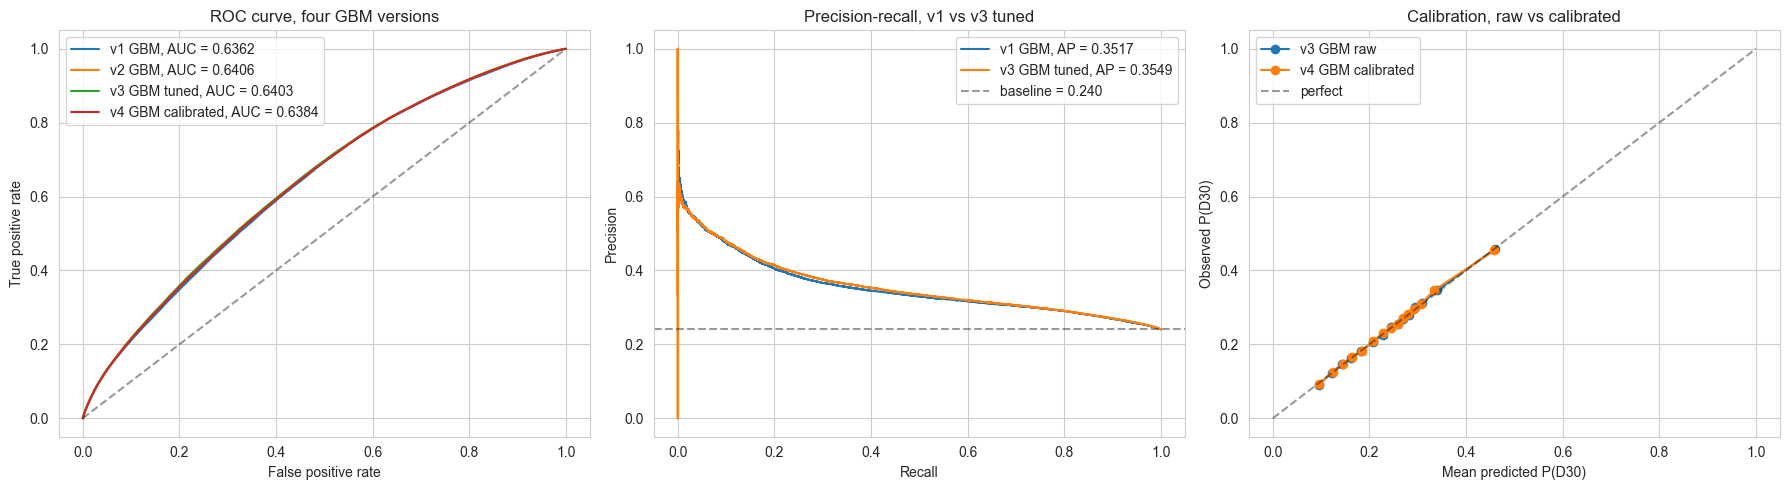

In [10]:
# ROC and calibration curves across the four GBM versions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for name, prob, auc in [
    ('v1 GBM', gbm_v1_prob, v1_results[1]['roc_auc']),
    ('v2 GBM', gbm_v2_prob, v2_results[1]['roc_auc']),
    ('v3 GBM tuned', gbm_v3_prob, v3_results[0]['roc_auc']),
    ('v4 GBM calibrated', gbm_v4_prob, v4_results[0]['roc_auc']),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name}, AUC = {auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve, four GBM versions'); ax.legend()

ax = axes[1]
for name, prob, ap in [
    ('v1 GBM', gbm_v1_prob, v1_results[1]['pr_auc']),
    ('v3 GBM tuned', gbm_v3_prob, v3_results[0]['pr_auc']),
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, label=f'{name}, AP = {ap:.4f}')
ax.axhline(y_test.mean(), color='black', ls='--', alpha=0.4, label=f'baseline = {y_test.mean():.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-recall, v1 vs v3 tuned'); ax.legend()

ax = axes[2]
for name, prob in [('v3 GBM raw', gbm_v3_prob), ('v4 GBM calibrated', gbm_v4_prob)]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=15, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='perfect')
ax.set_xlabel('Mean predicted P(D30)'); ax.set_ylabel('Observed P(D30)')
ax.set_title('Calibration, raw vs calibrated'); ax.legend()

plt.tight_layout()
plt.show()

## 7. Standardized logit coefficients, v1

From the baseline logit, signed by direction. Positive coefficients predict higher D30 retention. Useful as a sanity check on what the model latches onto.

In [11]:
coefs = pd.DataFrame({
    'feature': v1_features,
    'coef_std': logit_v1.named_steps['clf'].coef_[0],
}).sort_values('coef_std', key=abs, ascending=False).reset_index(drop=True)
print('v1 logit standardized coefficients (largest absolute first):')
print()
print(coefs.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))

v1 logit standardized coefficients (largest absolute first):

              feature  coef_std
       got_any_answer   +0.5110
hours_to_first_answer   -0.2267
got_answer_within_24h   -0.1473
       has_code_block   +0.1173
      log_body_length   +0.1133
             num_tags   +0.0674
          cohort_year   -0.0432
      hour_of_day_utc   +0.0391
 got_answer_within_1h   -0.0327
         title_length   -0.0185
            has_image   +0.0123
          day_of_week   -0.0112
           is_weekend   -0.0085
             has_link   +0.0085


## 8. SHAP for the tuned GBM

Tree explainer on a 30K-row sample of the test set. Want to see which features the v3 tuned model actually leans on, including the engineered interactions.

In [12]:
shap_sample_idx = np.random.RandomState(RNG).choice(len(X_test_v2), size=30_000, replace=False)
X_shap = X_test_v2.iloc[shap_sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(gbm_v3)
shap_values = explainer.shap_values(X_shap)

shap_imp = pd.DataFrame({
    'feature': X_v2.columns.tolist(),
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('Top 20 features by mean |SHAP| (v3 tuned GBM):')
print()
print(shap_imp.head(20).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Top 20 features by mean |SHAP| (v3 tuned GBM):

              feature  mean_abs_shap
        ans_x_logbody         0.1852
           ans_x_code         0.1213
hours_to_first_answer         0.1077
            tag_other         0.0519
          cohort_year         0.0477
             num_tags         0.0408
          htfa_x_code         0.0359
       got_any_answer         0.0323
       has_code_block         0.0253
      hour_of_day_utc         0.0251
      log_body_length         0.0214
         title_length         0.0172
          day_of_week         0.0166
got_answer_within_24h         0.0152
       tag_javascript         0.0145
 got_answer_within_1h         0.0114
              tag_c++         0.0065
          tag_flutter         0.0064
            tag_excel         0.0062
              tag_sql         0.0062


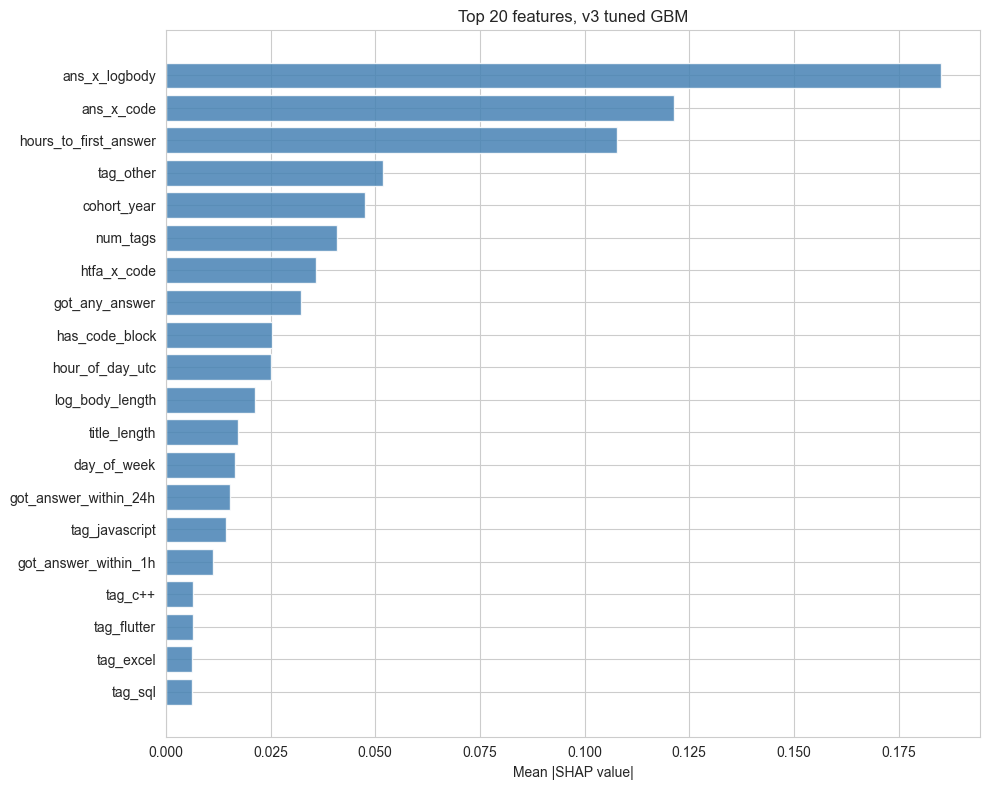

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
top20 = shap_imp.head(20)
y_pos = np.arange(len(top20))
ax.barh(y_pos, top20['mean_abs_shap'], color='steelblue', alpha=0.85)
ax.set_yticks(y_pos); ax.set_yticklabels(top20['feature'])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features, v3 tuned GBM')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Headline finding and save

The headline of this notebook is the structural ceiling. v1 baseline GBM gets 0.6362. v2 engineered features adds about half a percentage point. v3 tuning and v4 calibration on top of that move the number around within a tenth of a percentage point, sometimes up, sometimes down. The best AUC across all four versions is around 0.64.

What's missing from the feature set, and what would actually push the AUC higher, is text content of the question body and title. TF-IDF or sentence embeddings would carry signal about the question's clarity and quality that the existing numeric features only proxy weakly. Adding text would require re-running sql-04 with the body column kept, costing about 28 GB of BigQuery scan and roughly $0.14. Worth it if AUC matters for a downstream decision, not worth it for a portfolio piece whose causal-inference story already does the heavy lifting.

In [14]:
import os

# Save all-version metrics
all_results.to_parquet(f'{DATA_DIR}/predictive_metrics.parquet', index=False)

# Save SHAP from the tuned model
shap_imp.to_parquet(f'{DATA_DIR}/predictive_shap.parquet', index=False)

# Save v1 logit coefficients for the dashboard's interpretability section
coefs.to_parquet(f'{DATA_DIR}/predictive_logit_coefs.parquet', index=False)

print('Saved:')
for f in ['predictive_metrics.parquet', 'predictive_shap.parquet', 'predictive_logit_coefs.parquet']:
    p = f'{DATA_DIR}/{f}'
    print(f'  {p}  ({os.path.getsize(p)} bytes)')
print()
print('Headline:')
print(f'  v1 GBM baseline:        {v1_gbm_auc:.4f}')
print(f'  Best v2/v3/v4 ROC AUC:  {best_auc:.4f}')
print(f'  Improvement:            {(best_auc - v1_gbm_auc)*100:+.2f} pp')

Saved:
  ../data/processed/predictive_metrics.parquet  (3119 bytes)
  ../data/processed/predictive_shap.parquet  (2830 bytes)
  ../data/processed/predictive_logit_coefs.parquet  (2078 bytes)

Headline:
  v1 GBM baseline:        0.6362
  Best v2/v3/v4 ROC AUC:  0.6406
  Improvement:            +0.44 pp
